## Library Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("All libraries imported successfully.")

All libraries imported successfully.


## Load Data

In [ ]:

df_raw = pd.read_csv('household_power_consumption.txt', sep=';', low_memory=False)
print(f"Raw shape: {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")

df_raw['datetime'] = pd.to_datetime(df_raw['Date'] + ' ' + df_raw['Time'], format='%d/%m/%Y %H:%M:%S')
df_raw = df_raw.drop(columns=['Date', 'Time'])
df_raw = df_raw.set_index('datetime')


df_raw.replace('?', np.nan, inplace=True)


measurement_cols = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]
for col in measurement_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f"\nShape after parsing: {df_raw.shape}")
print(f"\nData types:\n{df_raw.dtypes}")
print(f"\nFirst 5 rows:")
print(df_raw.head())

Raw shape: (2075259, 9)
Columns: ['Date', 'Time', 'Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Shape after parsing: (2075259, 7)

Data types:
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

First 5 rows:
                     Global_active_power  Global_reactive_power  Voltage  \
datetime                                                                   
2006-12-16 17:24:00                4.216                  0.418   234.84   
2006-12-16 17:25:00                5.360                  0.436   233.63   
2006-12-16 17:26:00                5.374                  0.498   233.29   
2006-12-16 17:27:00                5.388                  0.502   233.74   
2006-12-16 17:28:00                3.666             

## Data Preprocessing

In [ ]:

df = df_raw.resample('h').mean()
print(f"Shape after hourly resampling: {df.shape}")


print(f"\nNull counts per column before imputation:")
print(df.isnull().sum())


df = df.ffill()

df = df.dropna()
print(f"\nShape after forward-fill and dropna: {df.shape}")
print(f"Null counts after imputation: {df.isnull().sum().sum()}")

cap_cols = ['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

for col in cap_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    original_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower=lower, upper=upper)
    print(f"{col}: capped {original_outliers} outliers to [{lower:.3f}, {upper:.3f}]")

print(f"\nShape after outlier capping: {df.shape}")

Shape after hourly resampling: (34589, 7)

Null counts per column before imputation:
Global_active_power      421
Global_reactive_power    421
Voltage                  421
Global_intensity         421
Sub_metering_1           421
Sub_metering_2           421
Sub_metering_3           421
dtype: int64

Shape after forward-fill and dropna: (34589, 7)
Null counts after imputation: 0
Global_active_power: capped 740 outliers to [-1.507, 3.425]
Sub_metering_1: capped 4989 outliers to [0.000, 0.000]
Sub_metering_2: capped 2616 outliers to [-0.975, 1.625]
Sub_metering_3: capped 0 outliers to [-19.500, 34.233]

Shape after outlier capping: (34589, 7)


## Leakage Check

In [ ]:

leaky_cols = ['Global_reactive_power', 'Voltage', 'Global_intensity']
df = df.drop(columns=leaky_cols)

print("Leaky features dropped. Remaining columns:")
print(df.columns.tolist())
print(f"\nDataset shape after leakage removal: {df.shape}")

Leaky features dropped. Remaining columns:
['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

Dataset shape after leakage removal: (34589, 4)


## Feature Engineering

In [ ]:

df['Hour'] = df.index.hour
df['DayOfWeek'] = df.index.dayofweek
df['Month'] = df.index.month
df['IsWeekend'] = (df.index.dayofweek >= 5).astype(int)


def get_season(month):
    if month in [12, 1, 2]: return 0
    elif month in [3, 4, 5]: return 1
    elif month in [6, 7, 8]: return 2
    else: return 3

df['Season'] = df.index.month.map(get_season)
df['IsBusinessHour'] = ((df.index.hour >= 9) & (df.index.hour <= 18)).astype(int)

df['Lag_1h'] = df['Global_active_power'].shift(1)
df['Lag_24h'] = df['Global_active_power'].shift(24)
df['Lag_168h'] = df['Global_active_power'].shift(168)


df['Sub_metering_remainder'] = (df['Global_active_power'] * 1000 / 60) - df['Sub_metering_1'] - df['Sub_metering_2'] - df['Sub_metering_3']


df = df.dropna()

print(f"Dataset shape after feature engineering: {df.shape}")
print(f"Features: {df.columns.tolist()}")

Dataset shape after feature engineering: (34421, 14)
Features: ['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'Season', 'IsBusinessHour', 'Lag_1h', 'Lag_24h', 'Lag_168h', 'Sub_metering_remainder']


## Train/Test Split


In [ ]:

X = df.drop(['Global_active_power', 'Sub_metering_remainder'], axis=1)
y = df['Global_active_power']


y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


train_bins = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
test_bins = pd.qcut(y_test, q=5, labels=False, duplicates='drop')
print("\nTrain target distribution (bin counts):")
print(train_bins.value_counts().sort_index())
print("\nTest target distribution (bin counts):")
print(test_bins.value_counts().sort_index())

Training set: (27536, 12), Test set: (6885, 12)

Train target distribution (bin counts):
Global_active_power
0    5510
1    5506
2    5506
3    5507
4    5507
Name: count, dtype: int64

Test target distribution (bin counts):
Global_active_power
0    1378
1    1376
2    1377
3    1377
4    1377
Name: count, dtype: int64


## Feature Scaling


In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
print("Scaling complete. Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Scaling complete. Train shape: (27536, 12)
Test shape: (6885, 12)


## Exploratory Data Analysis (EDA)


### Target Distribution


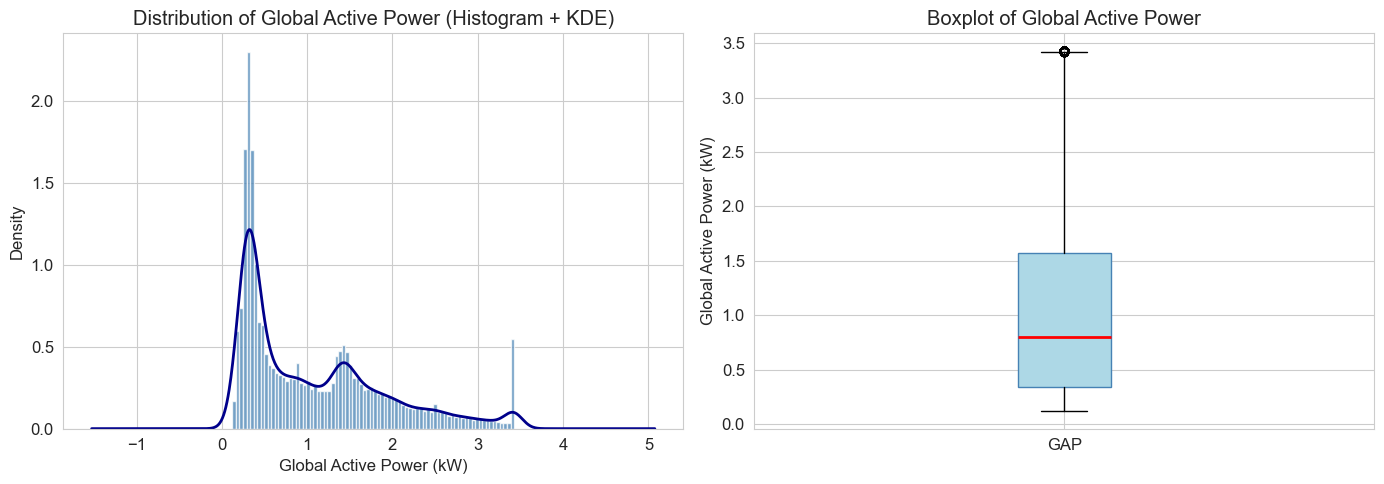

Mean:     1.0727 kW
Median:   0.8019 kW
Std:      0.8494 kW
Skewness: 1.0049
Kurtosis: 0.1796


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].hist(df['Global_active_power'], bins=80, edgecolor='white',
             color='steelblue', alpha=0.75, density=True)
df['Global_active_power'].plot.kde(ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_xlabel('Global Active Power (kW)')
axes[0].set_ylabel('Density')
axes[0].set_title('Distribution of Global Active Power (Histogram + KDE)')


axes[1].boxplot(df['Global_active_power'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Global Active Power (kW)')
axes[1].set_title('Boxplot of Global Active Power')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['GAP'])

plt.tight_layout()
plt.show()

print(f"Mean:     {df['Global_active_power'].mean():.4f} kW")
print(f"Median:   {df['Global_active_power'].median():.4f} kW")
print(f"Std:      {df['Global_active_power'].std():.4f} kW")
print(f"Skewness: {df['Global_active_power'].skew():.4f}")
print(f"Kurtosis: {df['Global_active_power'].kurtosis():.4f}")

### Hourly Consumption Heatmap by Day of Week

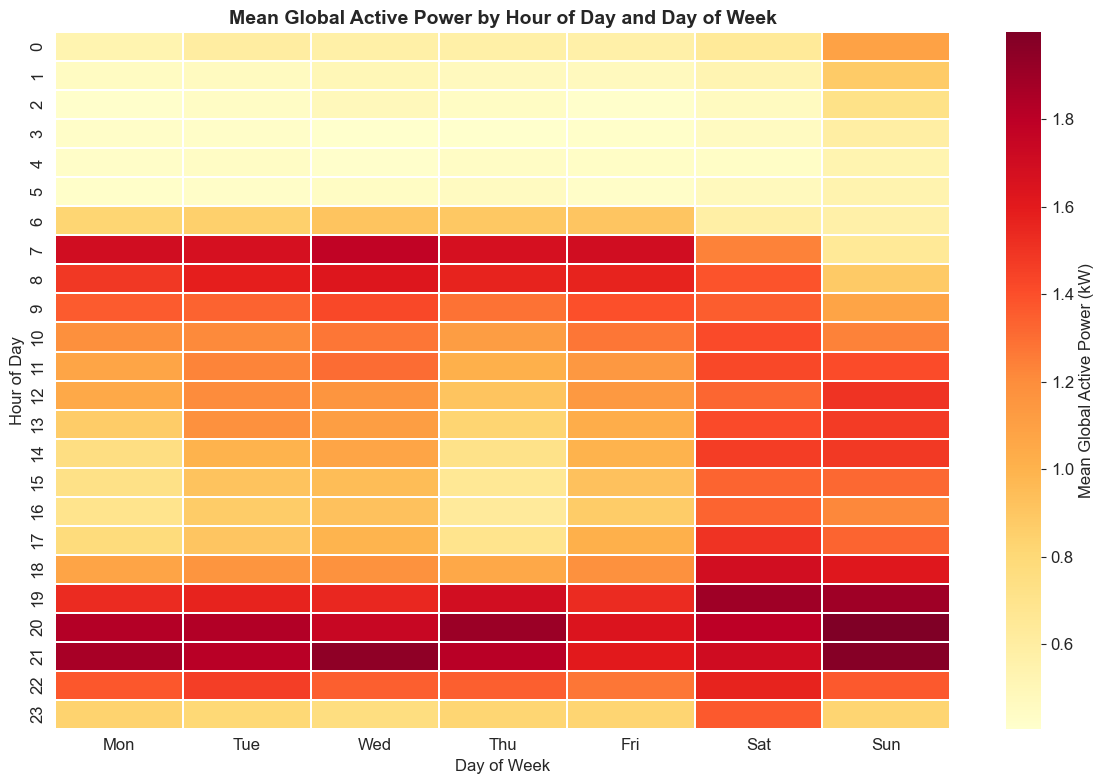

Top 5 peak consumption hours (mean kW):
Hour
20    1.822073
21    1.816483
19    1.667259
7     1.487487
8     1.443522
Name: Global_active_power, dtype: float64


In [9]:
pivot = df.pivot_table(
    values='Global_active_power',
    index='Hour',
    columns='DayOfWeek',
    aggfunc='mean'
)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot.columns = day_labels

plt.figure(figsize=(12, 8))
sns.heatmap(
    pivot,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    cbar_kws={'label': 'Mean Global Active Power (kW)'}
)
plt.title('Mean Global Active Power by Hour of Day and Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()

print("Top 5 peak consumption hours (mean kW):")
print(df.groupby('Hour')['Global_active_power'].mean().sort_values(ascending=False).head(5))

### Monthly Average Consumption

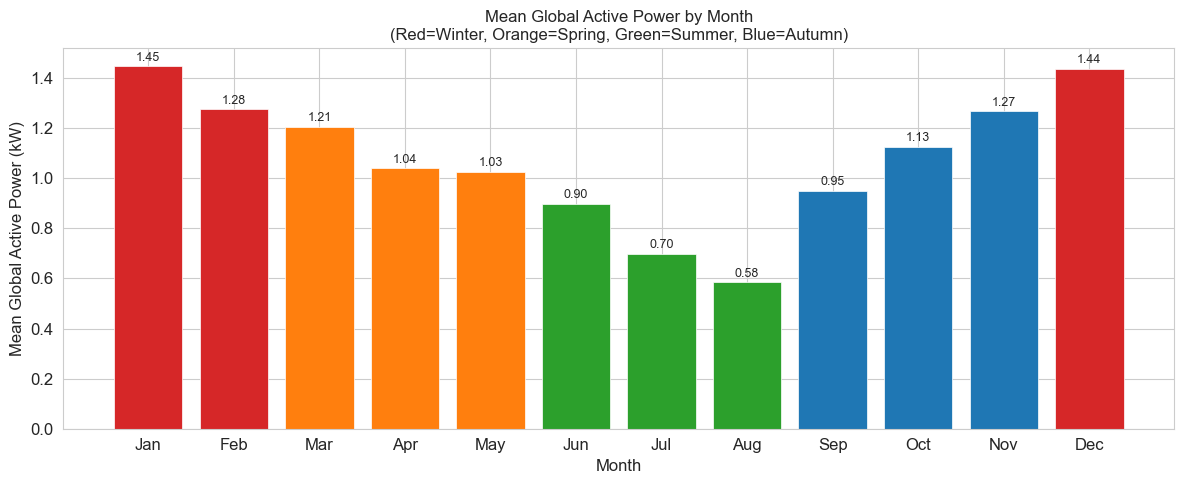

Monthly mean consumption (kW):
Month
1     1.448301
2     1.276525
3     1.206344
4     1.039342
5     1.025311
6     0.899155
7     0.699368
8     0.583983
9     0.950652
10    1.125262
11    1.268171
12    1.436933


In [10]:
monthly_mean = df.groupby('Month')['Global_active_power'].mean()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
colors = ['#d62728' if m in [12, 1, 2] else
          '#ff7f0e' if m in [3, 4, 5] else
          '#2ca02c' if m in [6, 7, 8] else '#1f77b4'
          for m in monthly_mean.index]
bars = plt.bar(monthly_mean.index, monthly_mean.values, color=colors, edgecolor='white', linewidth=0.5)
plt.xticks(range(1, 13), month_names)
plt.xlabel('Month')
plt.ylabel('Mean Global Active Power (kW)')
plt.title('Mean Global Active Power by Month\n(Red=Winter, Orange=Spring, Green=Summer, Blue=Autumn)',
          fontsize=12)
for bar, val in zip(bars, monthly_mean.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("Monthly mean consumption (kW):")
print(monthly_mean.to_string())

### Sub-Metering Breakdown by Month


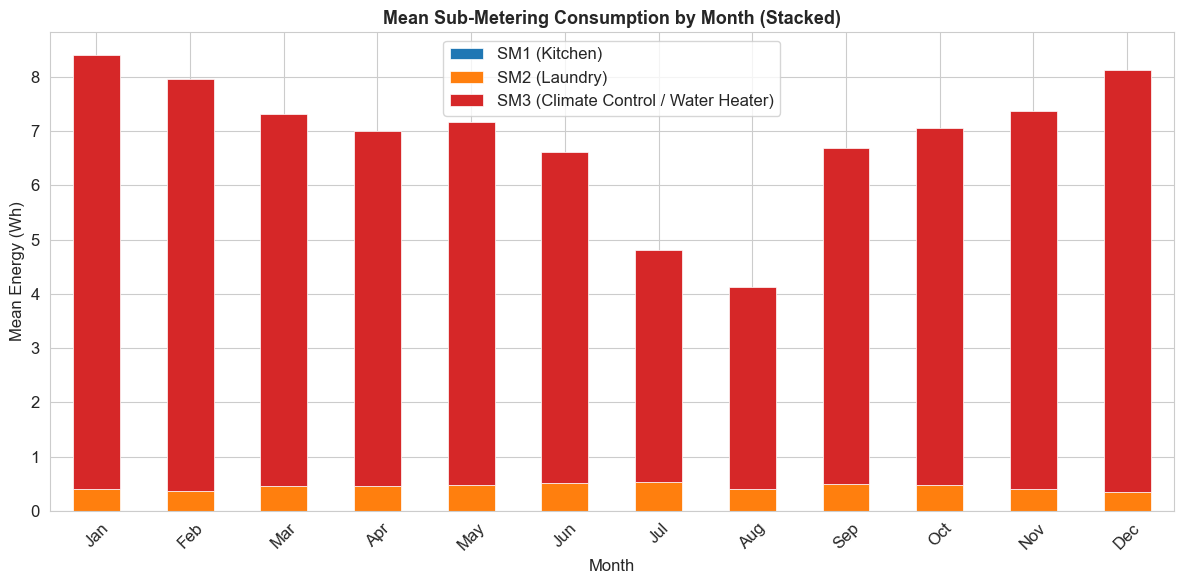

Mean sub-metering by month (Wh):
       Sub_metering_1  Sub_metering_2  Sub_metering_3
Month                                                
1                 0.0        0.410358        7.991603
2                 0.0        0.370038        7.585448
3                 0.0        0.448818        6.865697
4                 0.0        0.460909        6.534239
5                 0.0        0.469338        6.696740
6                 0.0        0.510861        6.110040
7                 0.0        0.531132        4.272538
8                 0.0        0.396239        3.735277
9                 0.0        0.488788        6.200013
10                0.0        0.474231        6.585445
11                0.0        0.405654        6.967952
12                0.0        0.347698        7.779302


In [11]:
sub_monthly = df.groupby('Month')[['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']].mean()

fig, ax = plt.subplots(figsize=(12, 6))
sub_monthly.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['#1f77b4', '#ff7f0e', '#d62728'],
    edgecolor='white',
    linewidth=0.5
)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names, rotation=45)
ax.set_xlabel('Month')
ax.set_ylabel('Mean Energy (Wh)')
ax.set_title('Mean Sub-Metering Consumption by Month (Stacked)', fontsize=13, fontweight='bold')
ax.legend(['SM1 (Kitchen)', 'SM2 (Laundry)', 'SM3 (Climate Control / Water Heater)'])
plt.tight_layout()
plt.show()

print("Mean sub-metering by month (Wh):")
print(sub_monthly.to_string())

### Correlation Heatmap

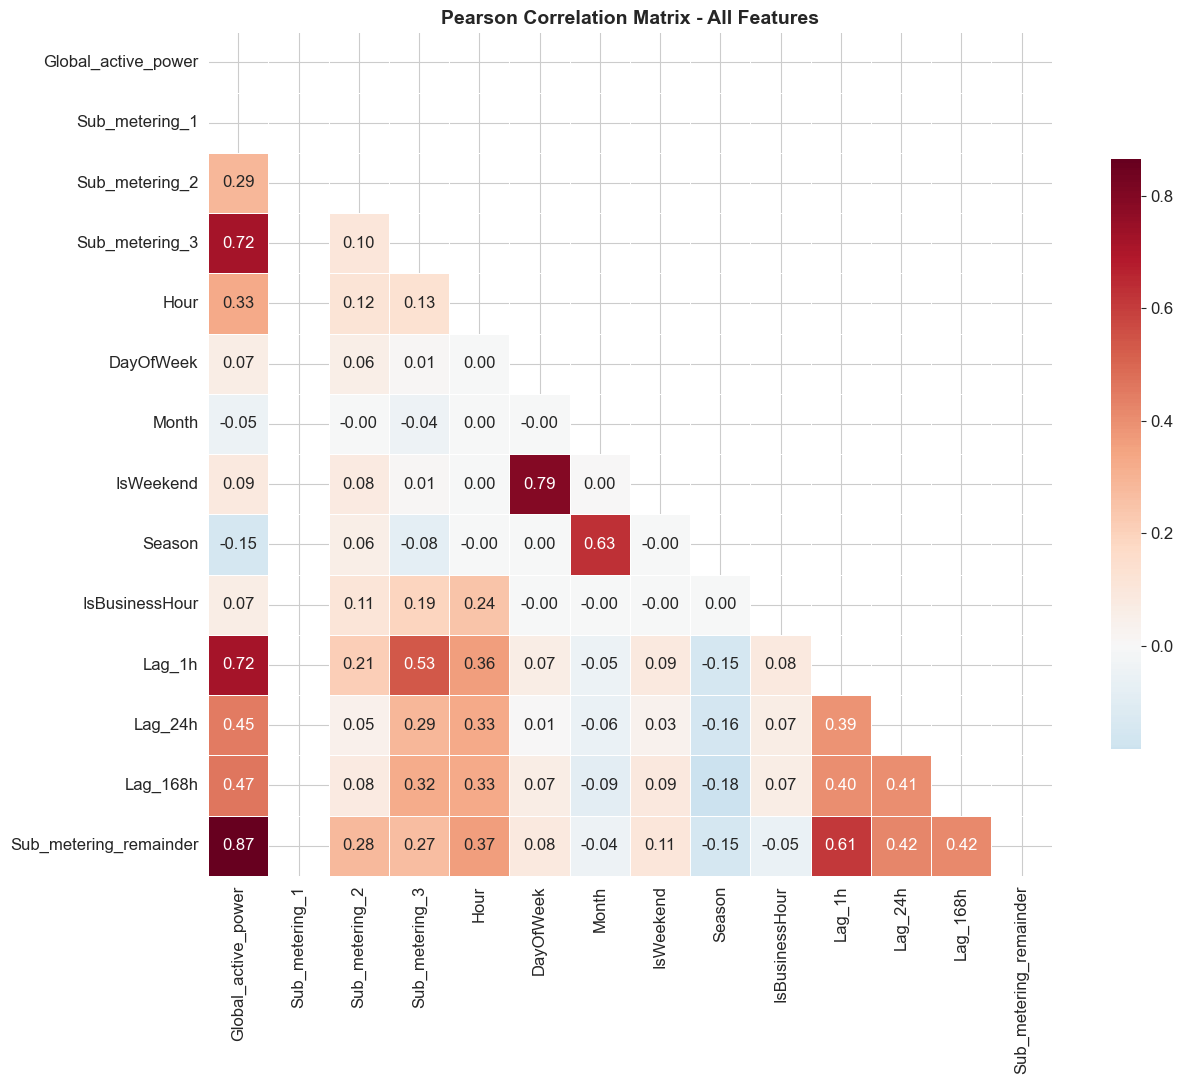

Top correlations with Global_active_power (by absolute value):
Sub_metering_remainder    0.865229
Lag_1h                    0.720124
Sub_metering_3            0.715109
Lag_168h                  0.466842
Lag_24h                   0.450780
Hour                      0.332457
Sub_metering_2            0.286154
Season                   -0.152287
IsWeekend                 0.085471
DayOfWeek                 0.067115
IsBusinessHour            0.067095
Month                    -0.051047
Sub_metering_1                 NaN


In [12]:
plt.figure(figsize=(14, 11))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.7}
)
plt.title('Pearson Correlation Matrix - All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top correlations with Global_active_power (by absolute value):")
print(corr_matrix['Global_active_power'].drop('Global_active_power')
      .sort_values(key=abs, ascending=False).to_string())

### Lag Feature Scatter Plots


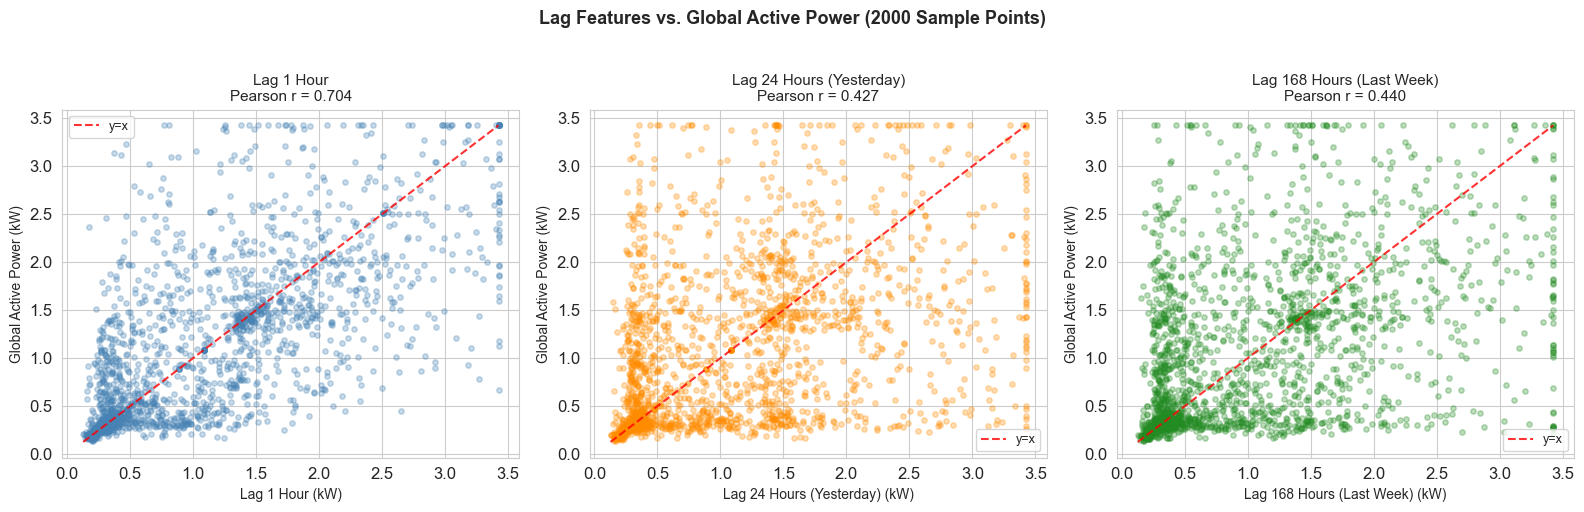

Lag_1h Pearson correlation with target: 0.7201
Lag_24h Pearson correlation with target: 0.4508
Lag_168h Pearson correlation with target: 0.4668


In [13]:
sample_df = df.sample(n=2000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
lag_features = ['Lag_1h', 'Lag_24h', 'Lag_168h']
lag_labels = ['Lag 1 Hour', 'Lag 24 Hours (Yesterday)', 'Lag 168 Hours (Last Week)']
colors = ['steelblue', 'darkorange', 'forestgreen']

for ax, lag, label, color in zip(axes, lag_features, lag_labels, colors):
    ax.scatter(sample_df[lag], sample_df['Global_active_power'],
               alpha=0.3, s=15, color=color)
    min_val = min(sample_df[lag].min(), sample_df['Global_active_power'].min())
    max_val = max(sample_df[lag].max(), sample_df['Global_active_power'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, alpha=0.8, label='y=x')
    corr_val = sample_df[[lag, 'Global_active_power']].corr().iloc[0, 1]
    ax.set_xlabel(f'{label} (kW)', fontsize=10)
    ax.set_ylabel('Global Active Power (kW)', fontsize=10)
    ax.set_title(f'{label}\nPearson r = {corr_val:.3f}', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle('Lag Features vs. Global Active Power (2000 Sample Points)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

for lag in lag_features:
    r = df[[lag, 'Global_active_power']].corr().iloc[0, 1]
    print(f"{lag} Pearson correlation with target: {r:.4f}")

## Feature Selection


### Pearson Correlation Ranking

Pearson Correlation with Global_active_power:
Sub_metering_remainder    0.865229
Lag_1h                    0.720124
Sub_metering_3            0.715109
Lag_168h                  0.466842
Lag_24h                   0.450780
Hour                      0.332457
Sub_metering_2            0.286154
IsWeekend                 0.085471
DayOfWeek                 0.067115
IsBusinessHour            0.067095
Month                    -0.051047
Season                   -0.152287
Sub_metering_1                 NaN
Name: Global_active_power, dtype: float64


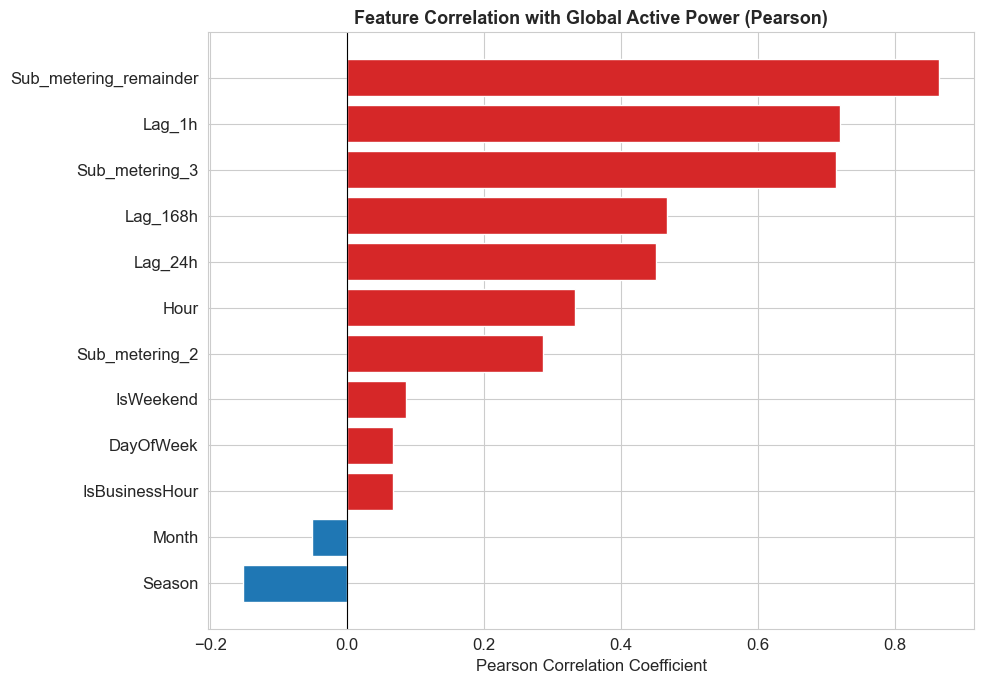

In [14]:
corr = df.corr()['Global_active_power'].drop('Global_active_power').sort_values(ascending=False)
print("Pearson Correlation with Global_active_power:")
print(corr)

plt.figure(figsize=(10, 7))
colors_corr = ['#d62728' if v > 0 else '#1f77b4' for v in corr.values]
plt.barh(corr.index[::-1], corr.values[::-1], color=colors_corr[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Feature Correlation with Global Active Power (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Random Forest Feature Importance

Random Forest Feature Importances:
Sub_metering_3    0.532965
Lag_1h            0.221440
Sub_metering_2    0.061375
Hour              0.052940
Lag_24h           0.044005
Lag_168h          0.038001
Month             0.018007
DayOfWeek         0.013131
IsBusinessHour    0.008490
Season            0.006935
IsWeekend         0.002711
Sub_metering_1    0.000000
dtype: float64


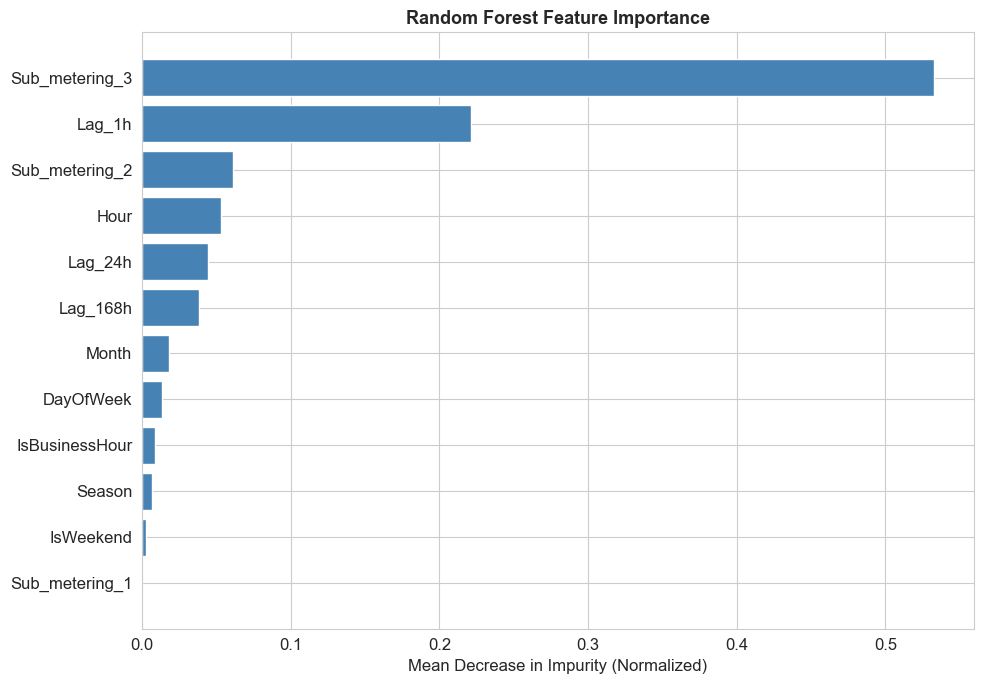


Features capturing ~80% of importance: ['Sub_metering_3', 'Lag_1h']


In [15]:
rf_fs = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fs.fit(X_train_scaled, y_train)
importances = pd.Series(rf_fs.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Random Forest Feature Importances:")
print(importances)

plt.figure(figsize=(10, 7))
plt.barh(importances.index[::-1], importances.values[::-1], color='steelblue', edgecolor='white')
plt.xlabel('Mean Decrease in Impurity (Normalized)')
plt.title('Random Forest Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

cumulative_importance = importances.cumsum()
top_features_80 = cumulative_importance[cumulative_importance <= 0.80].index.tolist()
print(f"\nFeatures capturing ~80% of importance: {top_features_80}")

## Model Building


In [ ]:
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=10000),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'KNeighbors': KNeighborsRegressor(n_neighbors=5, n_jobs=-1),
    'SVR': SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}


kf = KFold(n_splits=5, shuffle=True, random_state=42)
tscv = TimeSeriesSplit(n_splits=5)

results = {}


X_train_sorted = X_train_scaled.sort_index()
y_train_sorted = y_train.sort_index()

print(f"Training {len(models)} models...")
print("-" * 80)

for name, model in models.items():
    print(f"Training {name}...", end=' ')


    model.fit(X_train_scaled, y_train)


    y_pred = model.predict(X_test_scaled)


    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / np.clip(np.abs(y_test), 1e-8, None))) * 100
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)


    kf_scores = cross_val_score(model, X_train_scaled, y_train, cv=kf, scoring='r2', n_jobs=-1)


    tscv_scores = cross_val_score(model, X_train_sorted, y_train_sorted, cv=tscv, scoring='r2', n_jobs=-1)

    results[name] = {
        'MAE': mae,
        'MAPE': mape,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'KFold_CV_Mean': kf_scores.mean(),
        'KFold_CV_Std': kf_scores.std(),
        'TSCV_Mean': tscv_scores.mean(),
        'TSCV_Std': tscv_scores.std()
    }

    print(f"Done. R2={r2:.4f}, RMSE={rmse:.4f}")

print("-" * 80)
print("All models trained.")

Training 12 models...
--------------------------------------------------------------------------------
Training LinearRegression... Done. R2=0.7337, RMSE=0.4354
Training Ridge... Done. R2=0.7337, RMSE=0.4354
Training Lasso... Done. R2=0.7313, RMSE=0.4374
Training ElasticNet... Done. R2=0.7328, RMSE=0.4361
Training DecisionTree... Done. R2=0.6268, RMSE=0.5155
Training RandomForest... Done. R2=0.8156, RMSE=0.3624
Training GradientBoosting... Done. R2=0.8139, RMSE=0.3640
Training ExtraTrees... Done. R2=0.8200, RMSE=0.3580
Training KNeighbors... Done. R2=0.7552, RMSE=0.4175
Training SVR... Done. R2=0.7978, RMSE=0.3795
Training XGBoost... Done. R2=0.8156, RMSE=0.3624
Training LightGBM... Done. R2=0.8282, RMSE=0.3497
--------------------------------------------------------------------------------
All models trained.


In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2', ascending=False)
results_df = results_df.round(4)

print("\nModel Performance Summary (sorted by R2 descending):")
print(results_df[['MAE', 'MAPE', 'MSE', 'RMSE', 'R2']].to_string())

print("\nCross-Validation Summary:")
cv_summary = results_df[['R2', 'KFold_CV_Mean', 'KFold_CV_Std', 'TSCV_Mean', 'TSCV_Std']].copy()
cv_summary['KFold_CV (mean+/-std)'] = cv_summary.apply(
    lambda row: f"{row['KFold_CV_Mean']:.4f} +/- {row['KFold_CV_Std']:.4f}", axis=1)
cv_summary['TSCV (mean+/-std)'] = cv_summary.apply(
    lambda row: f"{row['TSCV_Mean']:.4f} +/- {row['TSCV_Std']:.4f}", axis=1)
print(cv_summary[['R2', 'KFold_CV (mean+/-std)', 'TSCV (mean+/-std)']].to_string())


Model Performance Summary (sorted by R2 descending):
                     MAE     MAPE     MSE    RMSE      R2
LightGBM          0.2258  24.1440  0.1223  0.3497  0.8282
ExtraTrees        0.2280  24.2974  0.1282  0.3580  0.8200
RandomForest      0.2317  24.5768  0.1313  0.3624  0.8156
XGBoost           0.2309  24.5701  0.1313  0.3624  0.8156
GradientBoosting  0.2433  27.0564  0.1325  0.3640  0.8139
SVR               0.2412  25.3212  0.1440  0.3795  0.7978
KNeighbors        0.2680  29.0947  0.1743  0.4175  0.7552
LinearRegression  0.3074  37.0887  0.1896  0.4354  0.7337
Ridge             0.3074  37.0888  0.1896  0.4354  0.7337
ElasticNet        0.3070  36.8319  0.1902  0.4361  0.7328
Lasso             0.3072  36.6320  0.1913  0.4374  0.7313
DecisionTree      0.3137  32.5188  0.2657  0.5155  0.6268

Cross-Validation Summary:
                      R2 KFold_CV (mean+/-std)  TSCV (mean+/-std)
LightGBM          0.8282     0.8269 +/- 0.0017  0.7982 +/- 0.0172
ExtraTrees        0.8200     0.81

## Model Optimisation


In [ ]:
top3_models = results_df.sort_values('R2', ascending=False).head(3).index.tolist()
print(f"Top 3 models by R2: {top3_models}")


param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'ExtraTrees': {
        'n_estimators': [100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7, -1],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [31, 63, 127],
        'subsample': [0.7, 0.8, 1.0]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 4, 5],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0]
    }
}

base_models_for_tuning = {
    'RandomForest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'ExtraTrees': ExtraTreesRegressor(random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBRegressor(random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42)
}

tuned_results = {}
tuned_models = {}

print("\nOptimising top 3 models with RandomizedSearchCV...")
print("-" * 80)

for model_name in top3_models:
    if model_name not in param_grids:
        print(f"No param grid defined for {model_name}, skipping tuning.")
        continue

    print(f"\nTuning {model_name}...")
    base_model = base_models_for_tuning[model_name]
    param_grid = param_grids[model_name]

    search = RandomizedSearchCV(
        base_model,
        param_grid,
        n_iter=30,
        cv=5,
        random_state=42,
        scoring='r2',
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train_scaled, y_train)

    print(f"  Best params: {search.best_params_}")
    print(f"  Best CV R2:  {search.best_score_:.4f}")

    best_model = search.best_estimator_
    y_pred_tuned = best_model.predict(X_test_scaled)

    mae_t = mean_absolute_error(y_test, y_pred_tuned)
    mape_t = np.mean(np.abs((y_test - y_pred_tuned) / np.clip(np.abs(y_test), 1e-8, None))) * 100
    mse_t = mean_squared_error(y_test, y_pred_tuned)
    rmse_t = np.sqrt(mse_t)
    r2_t = r2_score(y_test, y_pred_tuned)

    tuned_results[f'{model_name}_Tuned'] = {
        'MAE': mae_t,
        'MAPE': mape_t,
        'MSE': mse_t,
        'RMSE': rmse_t,
        'R2': r2_t,
        'Best_Params': search.best_params_,
        'CV_R2': search.best_score_
    }
    tuned_models[f'{model_name}_Tuned'] = best_model

    print(f"  Test R2 (tuned):   {r2_t:.4f}")
    print(f"  Test RMSE (tuned): {rmse_t:.4f}")

print("\n" + "-" * 80)
print("Tuning complete.")

print("\nTuned Model Results:")
for name, res in tuned_results.items():
    print(f"  {name}: MAE={res['MAE']:.4f}, MAPE={res['MAPE']:.2f}%, RMSE={res['RMSE']:.4f}, R2={res['R2']:.4f}")

Top 3 models by R2: ['LightGBM', 'ExtraTrees', 'RandomForest']

Optimising top 3 models with RandomizedSearchCV...
--------------------------------------------------------------------------------

Tuning LightGBM...
  Best params: {'subsample': 1.0, 'num_leaves': 31, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.05}
  Best CV R2:  0.8288
  Test R2 (tuned):   0.8296
  Test RMSE (tuned): 0.3483

Tuning ExtraTrees...
  Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
  Best CV R2:  0.8201
  Test R2 (tuned):   0.8182
  Test RMSE (tuned): 0.3597

Tuning RandomForest...
  Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}
  Best CV R2:  0.8218
  Test R2 (tuned):   0.8231
  Test RMSE (tuned): 0.3549

--------------------------------------------------------------------------------
Tuning complete.

Tuned Model Results:
  LightGBM_Tuned: MA

## Model Evaluation and Validation


### Full Comparison Table

In [ ]:
all_results = {}

for name, res in results.items():
    all_results[name] = {
        'MAE': res['MAE'],
        'MAPE': res['MAPE'],
        'MSE': res['MSE'],
        'RMSE': res['RMSE'],
        'R2': res['R2']
    }

for name, res in tuned_results.items():
    all_results[name] = {
        'MAE': res['MAE'],
        'MAPE': res['MAPE'],
        'MSE': res['MSE'],
        'RMSE': res['RMSE'],
        'R2': res['R2']
    }

full_comparison = pd.DataFrame(all_results).T.sort_values('R2', ascending=False).round(4)

print("Full Model Comparison Table (sorted by R2 descending):")
print(full_comparison.to_string())


try:
    styled = full_comparison.style \
        .highlight_min(subset=['MAE', 'MAPE', 'MSE', 'RMSE'], color='lightgreen') \
        .highlight_max(subset=['R2'], color='lightgreen') \
        .highlight_max(subset=['MAE', 'MAPE', 'MSE', 'RMSE'], color='#ffcccc') \
        .highlight_min(subset=['R2'], color='#ffcccc') \
        .format(precision=4)
    display(styled)
except Exception as e:
    print(f"(Styled display not available: {e})")

best_overall = full_comparison['R2'].idxmax()
print(f"\nBest overall model: {best_overall} (R2 = {full_comparison.loc[best_overall, 'R2']:.4f})")

Full Model Comparison Table (sorted by R2 descending):
                       MAE     MAPE     MSE    RMSE      R2
LightGBM_Tuned      0.2239  23.7581  0.1213  0.3483  0.8296
LightGBM            0.2258  24.1440  0.1223  0.3497  0.8282
RandomForest_Tuned  0.2306  25.1362  0.1260  0.3549  0.8231
ExtraTrees          0.2280  24.2974  0.1282  0.3580  0.8200
ExtraTrees_Tuned    0.2341  25.7076  0.1294  0.3597  0.8182
RandomForest        0.2317  24.5768  0.1313  0.3624  0.8156
XGBoost             0.2309  24.5701  0.1313  0.3624  0.8156
GradientBoosting    0.2433  27.0564  0.1325  0.3640  0.8139
SVR                 0.2412  25.3212  0.1440  0.3795  0.7978
KNeighbors          0.2680  29.0947  0.1743  0.4175  0.7552
LinearRegression    0.3074  37.0887  0.1896  0.4354  0.7337
Ridge               0.3074  37.0888  0.1896  0.4354  0.7337
ElasticNet          0.3070  36.8319  0.1902  0.4361  0.7328
Lasso               0.3072  36.6320  0.1913  0.4374  0.7313
DecisionTree        0.3137  32.5188  0.2657  

## Grouped RMSE Bar Chart: Baseline vs Tuned

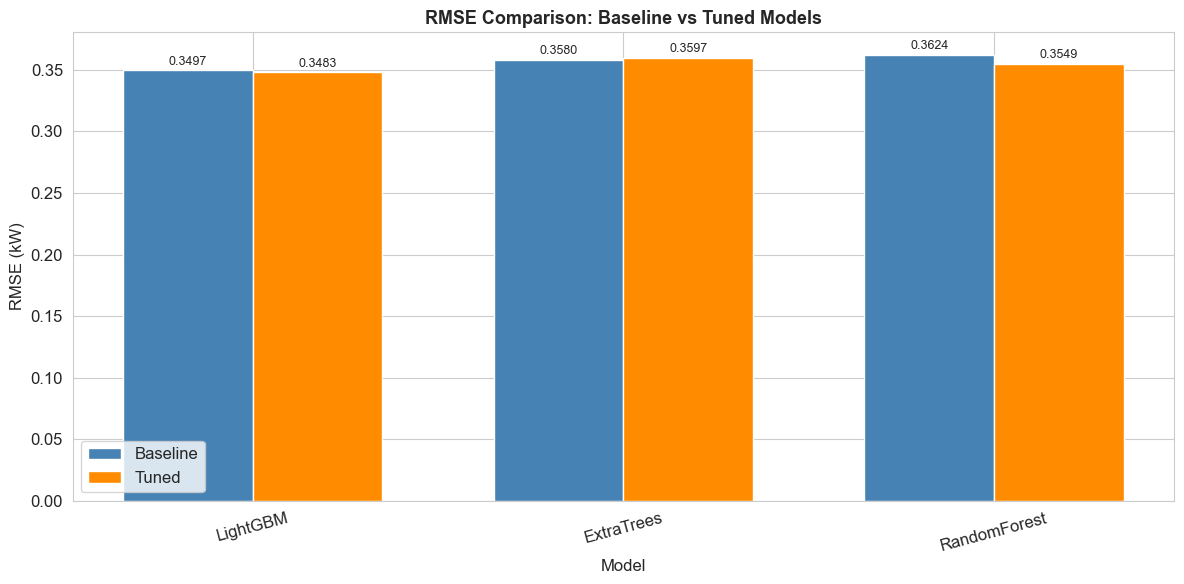

RMSE improvements from tuning:
  LightGBM: 0.3497 -> 0.3483 (+0.41% change)
  ExtraTrees: 0.3580 -> 0.3597 (-0.48% change)
  RandomForest: 0.3624 -> 0.3549 (+2.05% change)


In [ ]:

tuned_base_names = [name.replace('_Tuned', '') for name in tuned_results.keys()]
valid_names = [name for name in tuned_base_names if name in results]

baseline_rmse = [results[name]['RMSE'] for name in valid_names]
tuned_rmse = [tuned_results[f'{name}_Tuned']['RMSE'] for name in valid_names]

x = np.arange(len(valid_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, baseline_rmse, width, label='Baseline', color='steelblue', edgecolor='white')
bars2 = ax.bar(x + width/2, tuned_rmse, width, label='Tuned', color='darkorange', edgecolor='white')

ax.set_xlabel('Model')
ax.set_ylabel('RMSE (kW)')
ax.set_title('RMSE Comparison: Baseline vs Tuned Models', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(valid_names, rotation=15)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("RMSE improvements from tuning:")
for name, b_rmse, t_rmse in zip(valid_names, baseline_rmse, tuned_rmse):
    improvement = (b_rmse - t_rmse) / b_rmse * 100
    print(f"  {name}: {b_rmse:.4f} -> {t_rmse:.4f} ({improvement:+.2f}% change)")

### Predicted vs Actual Scatter Plot

Best model: LightGBM_Tuned (R2 = 0.8296)


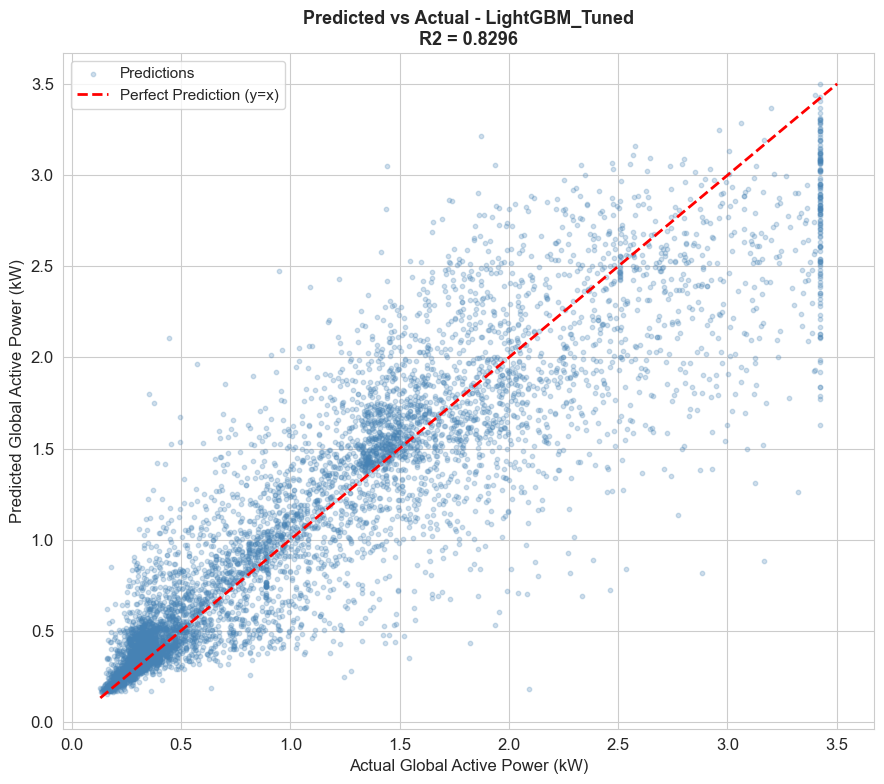

Mean residual:    0.0031 kW
Std of residuals: 0.3483 kW


In [ ]:

best_model_name = full_comparison['R2'].idxmax()
best_r2 = full_comparison.loc[best_model_name, 'R2']


if best_model_name in tuned_models:
    best_estimator = tuned_models[best_model_name]
else:
    best_estimator = models[best_model_name]

y_pred_best = best_estimator.predict(X_test_scaled)

print(f"Best model: {best_model_name} (R2 = {best_r2:.4f})")

plt.figure(figsize=(9, 8))
plt.scatter(y_test, y_pred_best, alpha=0.25, s=10, color='steelblue', label='Predictions')

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y=x)')

plt.xlabel('Actual Global Active Power (kW)', fontsize=12)
plt.ylabel('Predicted Global Active Power (kW)', fontsize=12)
plt.title(f'Predicted vs Actual - {best_model_name}\nR2 = {best_r2:.4f}',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

residuals = y_test.values - y_pred_best
print(f"Mean residual:    {residuals.mean():.4f} kW")
print(f"Std of residuals: {residuals.std():.4f} kW")

### Residual Distribution

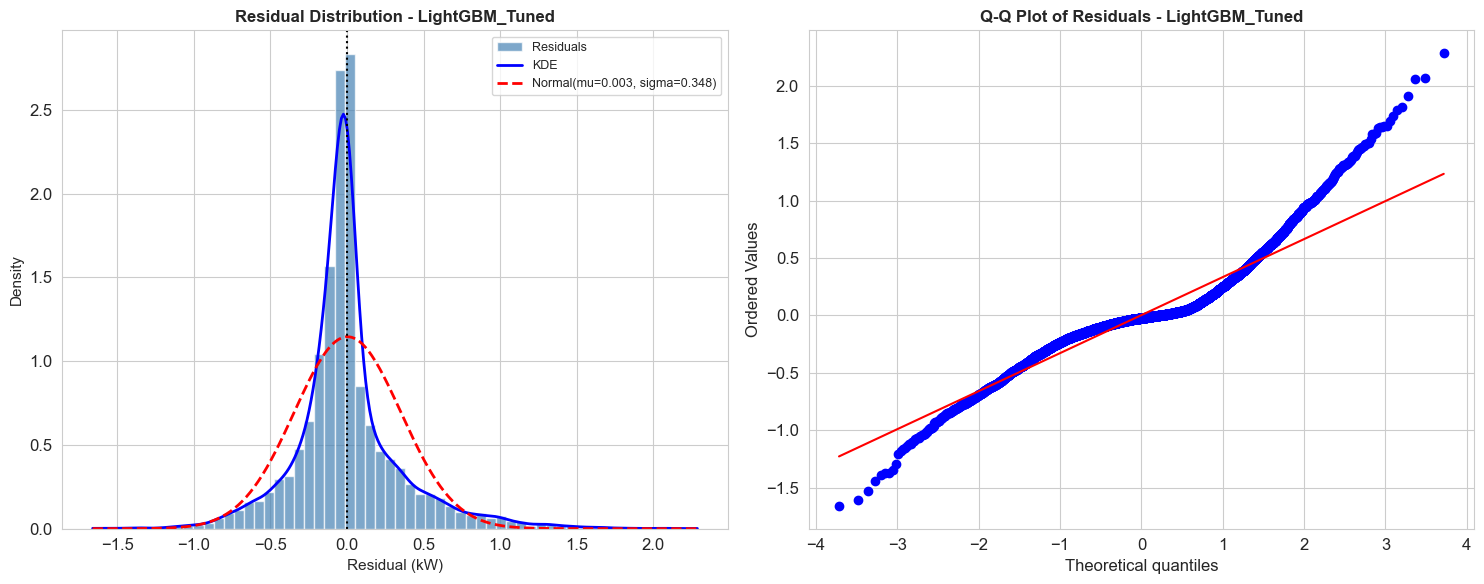

Shapiro-Wilk test (sample n=5000): statistic=0.9074, p-value=0.000000
Mean residual: 0.0031 kW  |  Std: 0.3483 kW
% residuals within +/- 1 RMSE: 78.2%


In [ ]:
from scipy import stats

residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].hist(residuals, bins=60, edgecolor='white', color='steelblue',
             alpha=0.7, density=True, label='Residuals')

kde_x = np.linspace(residuals.min(), residuals.max(), 300)
kde = stats.gaussian_kde(residuals)
axes[0].plot(kde_x, kde(kde_x), 'b-', linewidth=2, label='KDE')

mu, sigma = residuals.mean(), residuals.std()
normal_curve = stats.norm.pdf(kde_x, mu, sigma)
axes[0].plot(kde_x, normal_curve, 'r--', linewidth=2,
             label=f'Normal(mu={mu:.3f}, sigma={sigma:.3f})')
axes[0].axvline(0, color='black', linewidth=1.5, linestyle=':')
axes[0].set_xlabel('Residual (kW)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'Residual Distribution - {best_model_name}', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)


stats.probplot(residuals, dist='norm', plot=axes[1])
axes[1].set_title(f'Q-Q Plot of Residuals - {best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

sample_res = np.random.choice(residuals, size=min(5000, len(residuals)), replace=False)
stat_sw, p_val = stats.shapiro(sample_res)
print(f"Shapiro-Wilk test (sample n={len(sample_res)}): statistic={stat_sw:.4f}, p-value={p_val:.6f}")
print(f"Mean residual: {mu:.4f} kW  |  Std: {sigma:.4f} kW")
print(f"% residuals within +/- 1 RMSE: {(np.abs(residuals) <= sigma).mean()*100:.1f}%")

### Actual vs Predicted Time Series (First 500 Test Points)

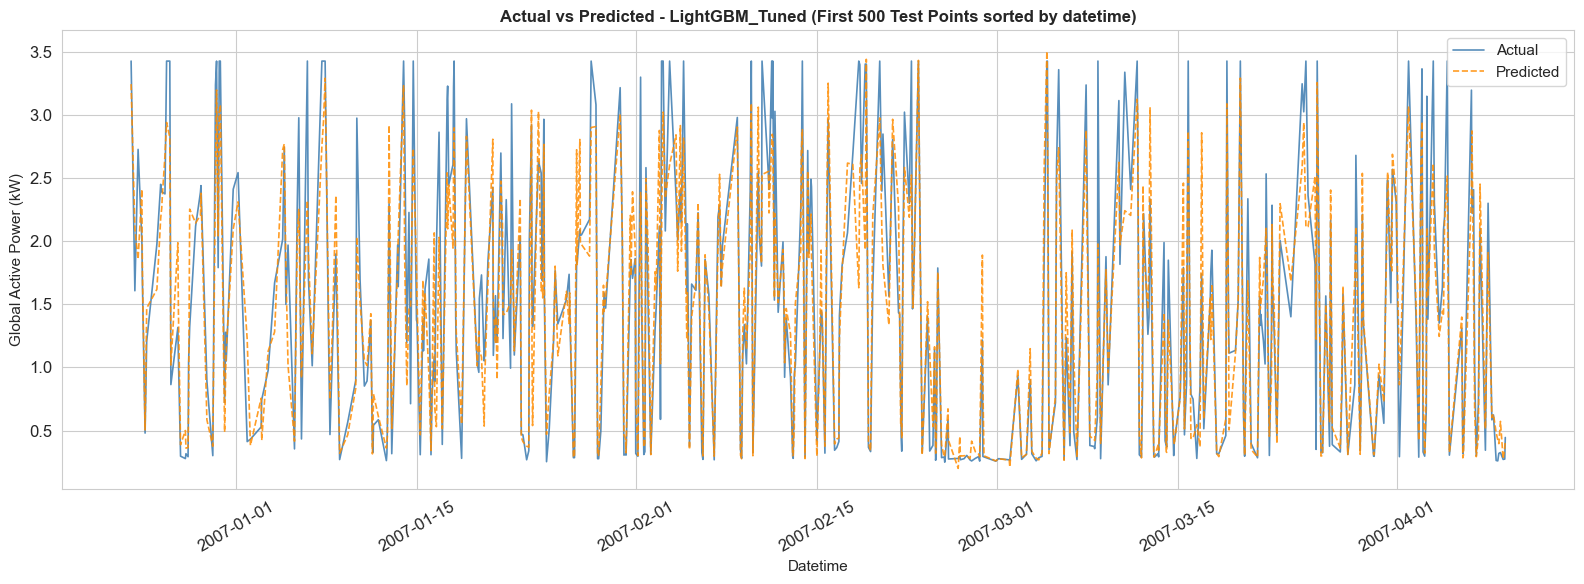

Plotted first 500 test observations sorted by datetime index.
Period: 2006-12-23 20:00:00 to 2007-04-09 09:00:00
MAE over plotted segment: 0.2808 kW


In [ ]:

test_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_best
}, index=y_test.index).sort_index()


n_points = min(500, len(test_df))
plot_df = test_df.head(n_points)

plt.figure(figsize=(16, 6))
plt.plot(plot_df.index, plot_df['Actual'],
         label='Actual', color='steelblue', linewidth=1.2, alpha=0.9)
plt.plot(plot_df.index, plot_df['Predicted'],
         label='Predicted', color='darkorange', linewidth=1.2, alpha=0.85, linestyle='--')
plt.xlabel('Datetime', fontsize=11)
plt.ylabel('Global Active Power (kW)', fontsize=11)
plt.title(f'Actual vs Predicted - {best_model_name} (First {n_points} Test Points sorted by datetime)',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f"Plotted first {n_points} test observations sorted by datetime index.")
print(f"Period: {plot_df.index[0]} to {plot_df.index[-1]}")
print(f"MAE over plotted segment: {np.mean(np.abs(plot_df['Actual'] - plot_df['Predicted'])):.4f} kW")